# IV.2.2 — Analisis Distribusi Posisi dan Perbedaan Spasial

Notebook ini dikhususkan untuk menghasilkan dua visualisasi:
1. **Distribusi Posisi Pergelangan Tangan per Penutur** (Boxplot 4 Panel)
2. **Perbedaan Posisi Pergelangan Tangan antar Penutur** (Heatmap Jarak Pairwise beserta Uji Signifikansi)


In [61]:
!pip install statsmodels

In [62]:
import pickle
import numpy as np
import pandas as pd
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import wilcoxon
import statsmodels.stats.multitest as smm
import itertools
import warnings
warnings.filterwarnings('ignore')

PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
speakers = sorted(set(v.split('_')[0] for v in video_ids))
speakers = [s for s in speakers if s in ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
signer_labels = [f"P{s[1:]}" for s in speakers]

WRIST_LH = 0
WRIST_RH = 21

print("Data loaded successfully.")


Data loaded successfully.


In [63]:
# ── 1. Ekstraksi Centroid Tingkat Video ─────────────────────────────────────

centroids = []

for vid in video_ids:

    parts = vid.split('_')

    sp = parts[0]

    if sp not in speakers:
        continue

    # Ambil hanya kode kalimat (S01, S02, dst.)
    sentence = parts[1]

    kp = data[vid]['keypoints']

    # ── Left Wrist ───────────────────────────────────────────────────────────
    w_l = kp[:, WRIST_LH, :]

    valid_l = ~(
        (w_l[:, 0] == 0) &
        (w_l[:, 1] == 0)
    )

    if valid_l.sum() > 0:
        lh_x = np.mean(w_l[valid_l, 0])
        lh_y = np.mean(w_l[valid_l, 1])
    else:
        lh_x = np.nan
        lh_y = np.nan

    # ── Right Wrist ──────────────────────────────────────────────────────────
    w_r = kp[:, WRIST_RH, :]

    valid_r = ~(
        (w_r[:, 0] == 0) &
        (w_r[:, 1] == 0)
    )

    if valid_r.sum() > 0:
        rh_x = np.mean(w_r[valid_r, 0])
        rh_y = np.mean(w_r[valid_r, 1])
    else:
        rh_x = np.nan
        rh_y = np.nan

    centroids.append({
        'vid': vid,
        'signer': sp,
        'sentence': sentence,
        'lh_x': lh_x,
        'lh_y': lh_y,
        'rh_x': rh_x,
        'rh_y': rh_y
    })

# ── DataFrame ────────────────────────────────────────────────────────────────

df = pd.DataFrame(centroids)

# ── Ringkasan Dataset ────────────────────────────────────────────────────────

print(f"Total video            : {len(df)}")
print(f"Jumlah penutur         : {df['signer'].nunique()}")
print(f"Jumlah kalimat unik    : {df['sentence'].nunique()}")

print("\nDaftar kalimat:")
print(sorted(df['sentence'].unique()))

print("\nJumlah video per penutur:")
print(df.groupby('signer').size().sort_index())

print("\nJumlah video per kalimat:")
print(df.groupby('sentence').size().sort_index())

print("\nContoh data:")
display(df.head())

print(f"\nCentroids extracted for {len(df)} videos.")

Total video            : 807
Jumlah penutur         : 6
Jumlah kalimat unik    : 30

Daftar kalimat:
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30']

Jumlah video per penutur:
signer
P1    150
P2    150
P3    150
P4    150
P5    150
P6     57
dtype: int64

Jumlah video per kalimat:
sentence
S01    27
S02    27
S03    27
S04    27
S05    27
S06    27
S07    27
S08    27
S09    27
S10    27
S11    27
S12    27
S13    27
S14    27
S15    27
S16    27
S17    27
S18    27
S19    27
S20    27
S21    27
S22    27
S23    27
S24    27
S25    27
S26    26
S27    27
S28    26
S29    26
S30    27
dtype: int64

Contoh data:


,vid,signer,sentence,lh_x,lh_y,rh_x,rh_y
0,P1_S01_R1,P1,S01,0.676288,0.755833,0.379277,0.659822
1,P1_S01_R2,P1,S01,0.668136,0.767573,0.365567,0.687786
2,P1_S01_R3,P1,S01,0.657746,0.764675,0.361257,0.661231
3,P1_S01_R4,P1,S01,0.654409,0.755608,0.360064,0.674925
4,P1_S01_R5,P1,S01,0.660736,0.758686,0.359632,0.667510



Centroids extracted for 807 videos.


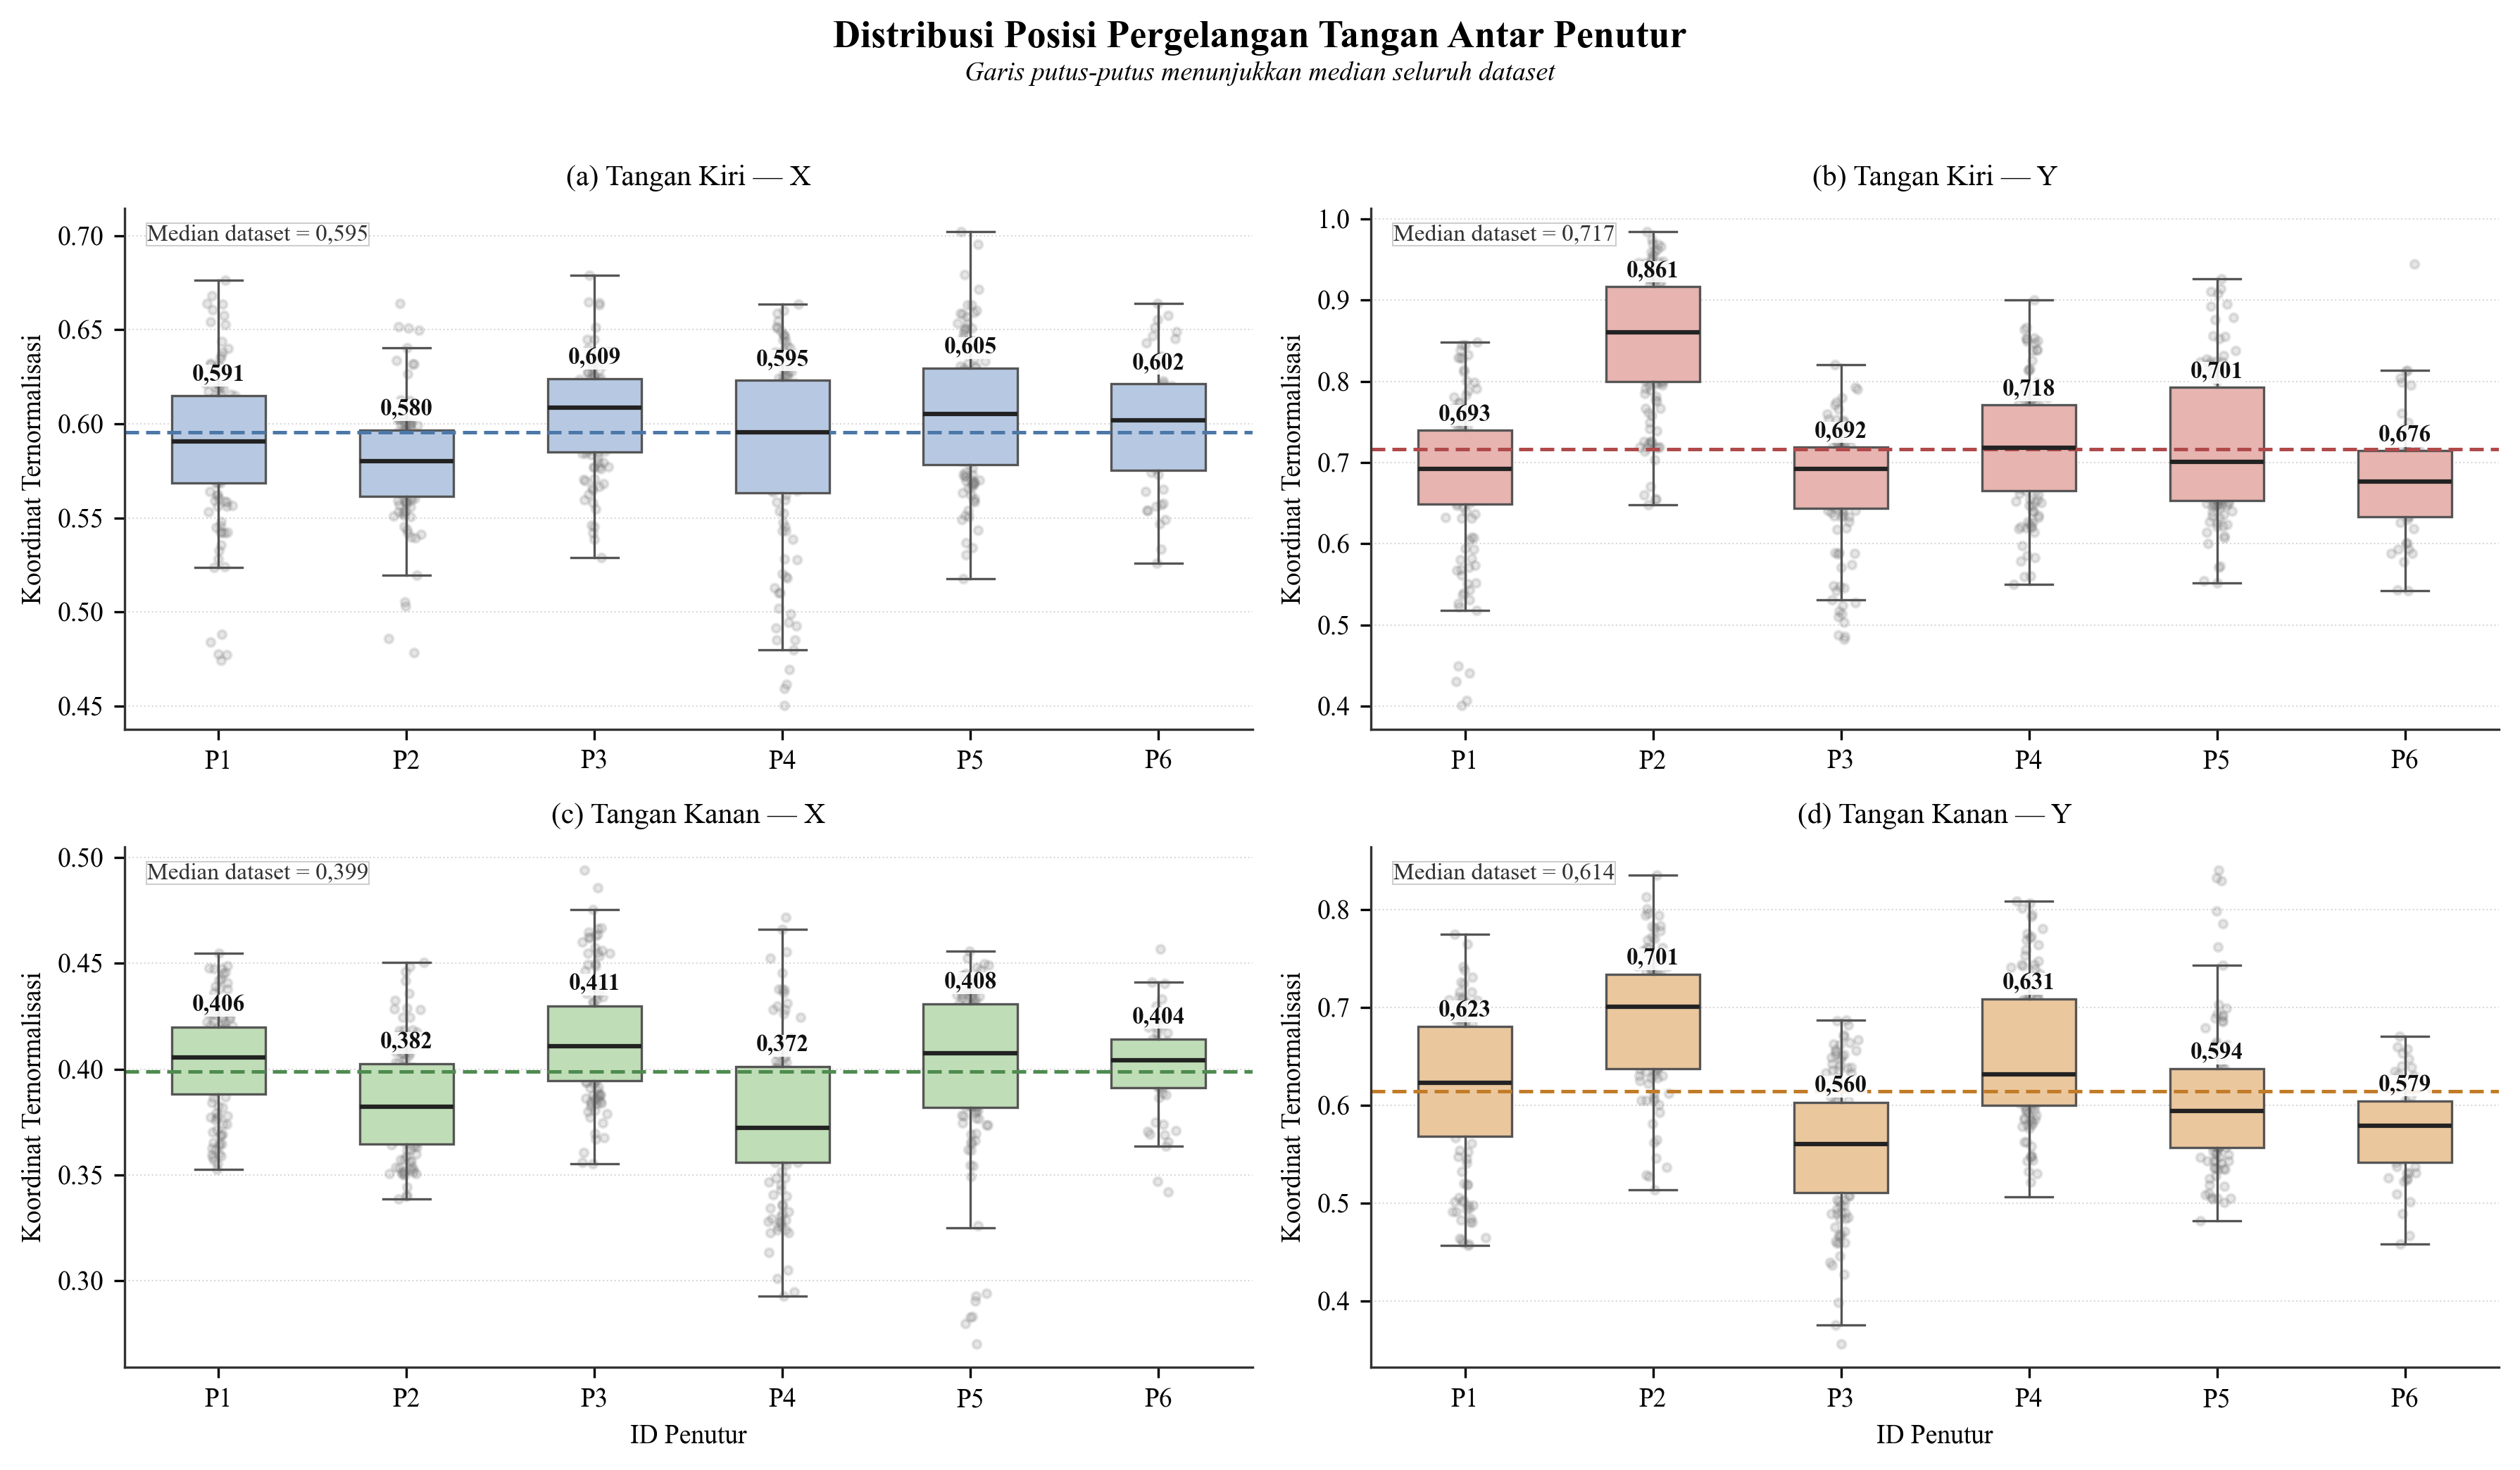

[SAVED] ../data/results\spatial_distribution_boxplot_final.png


In [76]:
# ── Gambar 1: Distribusi Posisi Pergelangan Tangan Antar Penutur ─────────────

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7),
    dpi=300
)

panels = [
    {
        'ax': axes[0,0],
        'var': 'lh_x',
        'title': '(a) Tangan Kiri — X',
        'color': '#B7C9E2',
        'line_c': '#4C78A8'
    },
    {
        'ax': axes[0,1],
        'var': 'lh_y',
        'title': '(b) Tangan Kiri — Y',
        'color': '#E7B4B0',
        'line_c': '#B04A4A'
    },
    {
        'ax': axes[1,0],
        'var': 'rh_x',
        'title': '(c) Tangan Kanan — X',
        'color': '#BFDDB6',
        'line_c': '#4E8B4F'
    },
    {
        'ax': axes[1,1],
        'var': 'rh_y',
        'title': '(d) Tangan Kanan — Y',
        'color': '#EBC79E',
        'line_c': '#C27C28'
    },
]

for p in panels:

    ax = p['ax']
    var = p['var']

    data_list = [
        df[df['signer'] == sp][var].dropna().values
        for sp in speakers
    ]

    median_dataset = df[var].median()

    # Boxplot
    bp = ax.boxplot(
        data_list,
        positions=np.arange(len(speakers)),
        widths=0.50,
        patch_artist=True,
        showfliers=False,

        medianprops=dict(
            color='#222222',
            linewidth=1.5
        ),

        boxprops=dict(
            facecolor=p['color'],
            edgecolor='#555555',
            linewidth=0.8
        ),

        whiskerprops=dict(
            color='#555555',
            linewidth=0.8
        ),

        capprops=dict(
            color='#555555',
            linewidth=0.8
        )
    )

    # Titik distribusi
    for i, sp_data in enumerate(data_list):

        n_show = min(120, len(sp_data))

        idx = np.random.choice(
            len(sp_data),
            n_show,
            replace=False
        )

        sampled = sp_data[idx]

        x_jitter = np.random.normal(
            i,
            0.035,
            size=n_show
        )

        ax.scatter(
            x_jitter,
            sampled,
            s=8,
            color='#777777',
            alpha=0.18,
            zorder=1
        )

        # Median per penutur
        med = np.median(sp_data)

        q3 = np.percentile(sp_data, 75)

        ax.text(
            i,
            q3 + 0.005,
            f'{med:.3f}'.replace('.', ','),

            ha='center',
            va='bottom',

            fontsize=8,
            fontweight='semibold',

            color='#111111',

            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.90,
                pad=0.05
            ),

            zorder=10
        )

    # Median dataset
    ax.axhline(
        median_dataset,
        color=p['line_c'],
        linestyle=(0, (4, 2)),
        linewidth=1.2,
        zorder=2
    )

    ax.text(
        0.02,
        0.97,
        f'Median dataset = {median_dataset:.3f}'.replace('.', ','),

        transform=ax.transAxes,

        ha='left',
        va='top',

        fontsize=8,

        color='#333333',

        bbox=dict(
            facecolor='white',
            edgecolor='#CCCCCC',
            linewidth=0.5,
            alpha=0.95,
            pad=0.25
        )
    )

    # Grid tipis
    ax.grid(
        axis='y',
        linestyle=':',
        linewidth=0.5,
        color='#D8D8D8'
    )

    ax.set_axisbelow(True)

    ax.set_xticks(np.arange(len(speakers)))
    ax.set_xticklabels(signer_labels)

    ax.set_ylabel(
        'Koordinat Ternormalisasi',
        fontsize=9
    )

    if ax in axes[1]:
        ax.set_xlabel(
            'ID Penutur',
            fontsize=9
        )

    ax.set_title(
        p['title'],
        fontsize=10,
        fontweight='normal',
        pad=8
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Distribusi Posisi Pergelangan Tangan Antar Penutur',
    fontsize=13,
    fontweight='bold',
    y=0.985
)

fig.text(
    0.5,
    0.945,
    'Garis putus-putus menunjukkan median seluruh dataset',
    ha='center',
    fontsize=9,
    style='italic'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_distribution_boxplot_final.png'
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"[SAVED] {save_path}")

In [77]:
for var in ['lh_x', 'lh_y', 'rh_x', 'rh_y']:

    print(f"\n{var.upper()}")

    for sp in speakers:

        x = df[df['signer'] == sp][var].dropna()

        q1 = x.quantile(0.25)
        med = x.median()
        q3 = x.quantile(0.75)

        print(
            f"{sp}: "
            f"Median={med:.3f}, "
            f"IQR={q3-q1:.3f} "
            f"(Q1={q1:.3f}, Q3={q3:.3f})"
        )


LH_X
P1: Median=0.591, IQR=0.047 (Q1=0.569, Q3=0.615)
P2: Median=0.580, IQR=0.035 (Q1=0.561, Q3=0.597)
P3: Median=0.609, IQR=0.039 (Q1=0.585, Q3=0.624)
P4: Median=0.595, IQR=0.060 (Q1=0.563, Q3=0.623)
P5: Median=0.605, IQR=0.051 (Q1=0.578, Q3=0.630)
P6: Median=0.602, IQR=0.046 (Q1=0.575, Q3=0.621)

LH_Y
P1: Median=0.693, IQR=0.092 (Q1=0.648, Q3=0.740)
P2: Median=0.861, IQR=0.118 (Q1=0.799, Q3=0.917)
P3: Median=0.692, IQR=0.076 (Q1=0.643, Q3=0.719)
P4: Median=0.718, IQR=0.105 (Q1=0.665, Q3=0.771)
P5: Median=0.701, IQR=0.140 (Q1=0.653, Q3=0.793)
P6: Median=0.676, IQR=0.081 (Q1=0.634, Q3=0.715)

RH_X
P1: Median=0.406, IQR=0.032 (Q1=0.388, Q3=0.420)
P2: Median=0.382, IQR=0.038 (Q1=0.364, Q3=0.402)
P3: Median=0.411, IQR=0.035 (Q1=0.394, Q3=0.430)
P4: Median=0.372, IQR=0.045 (Q1=0.356, Q3=0.401)
P5: Median=0.408, IQR=0.049 (Q1=0.382, Q3=0.431)
P6: Median=0.404, IQR=0.023 (Q1=0.391, Q3=0.414)

RH_Y
P1: Median=0.623, IQR=0.112 (Q1=0.568, Q3=0.680)
P2: Median=0.701, IQR=0.096 (Q1=0.637, Q3=0.7

In [65]:
sentence = vid.split('_')[1]

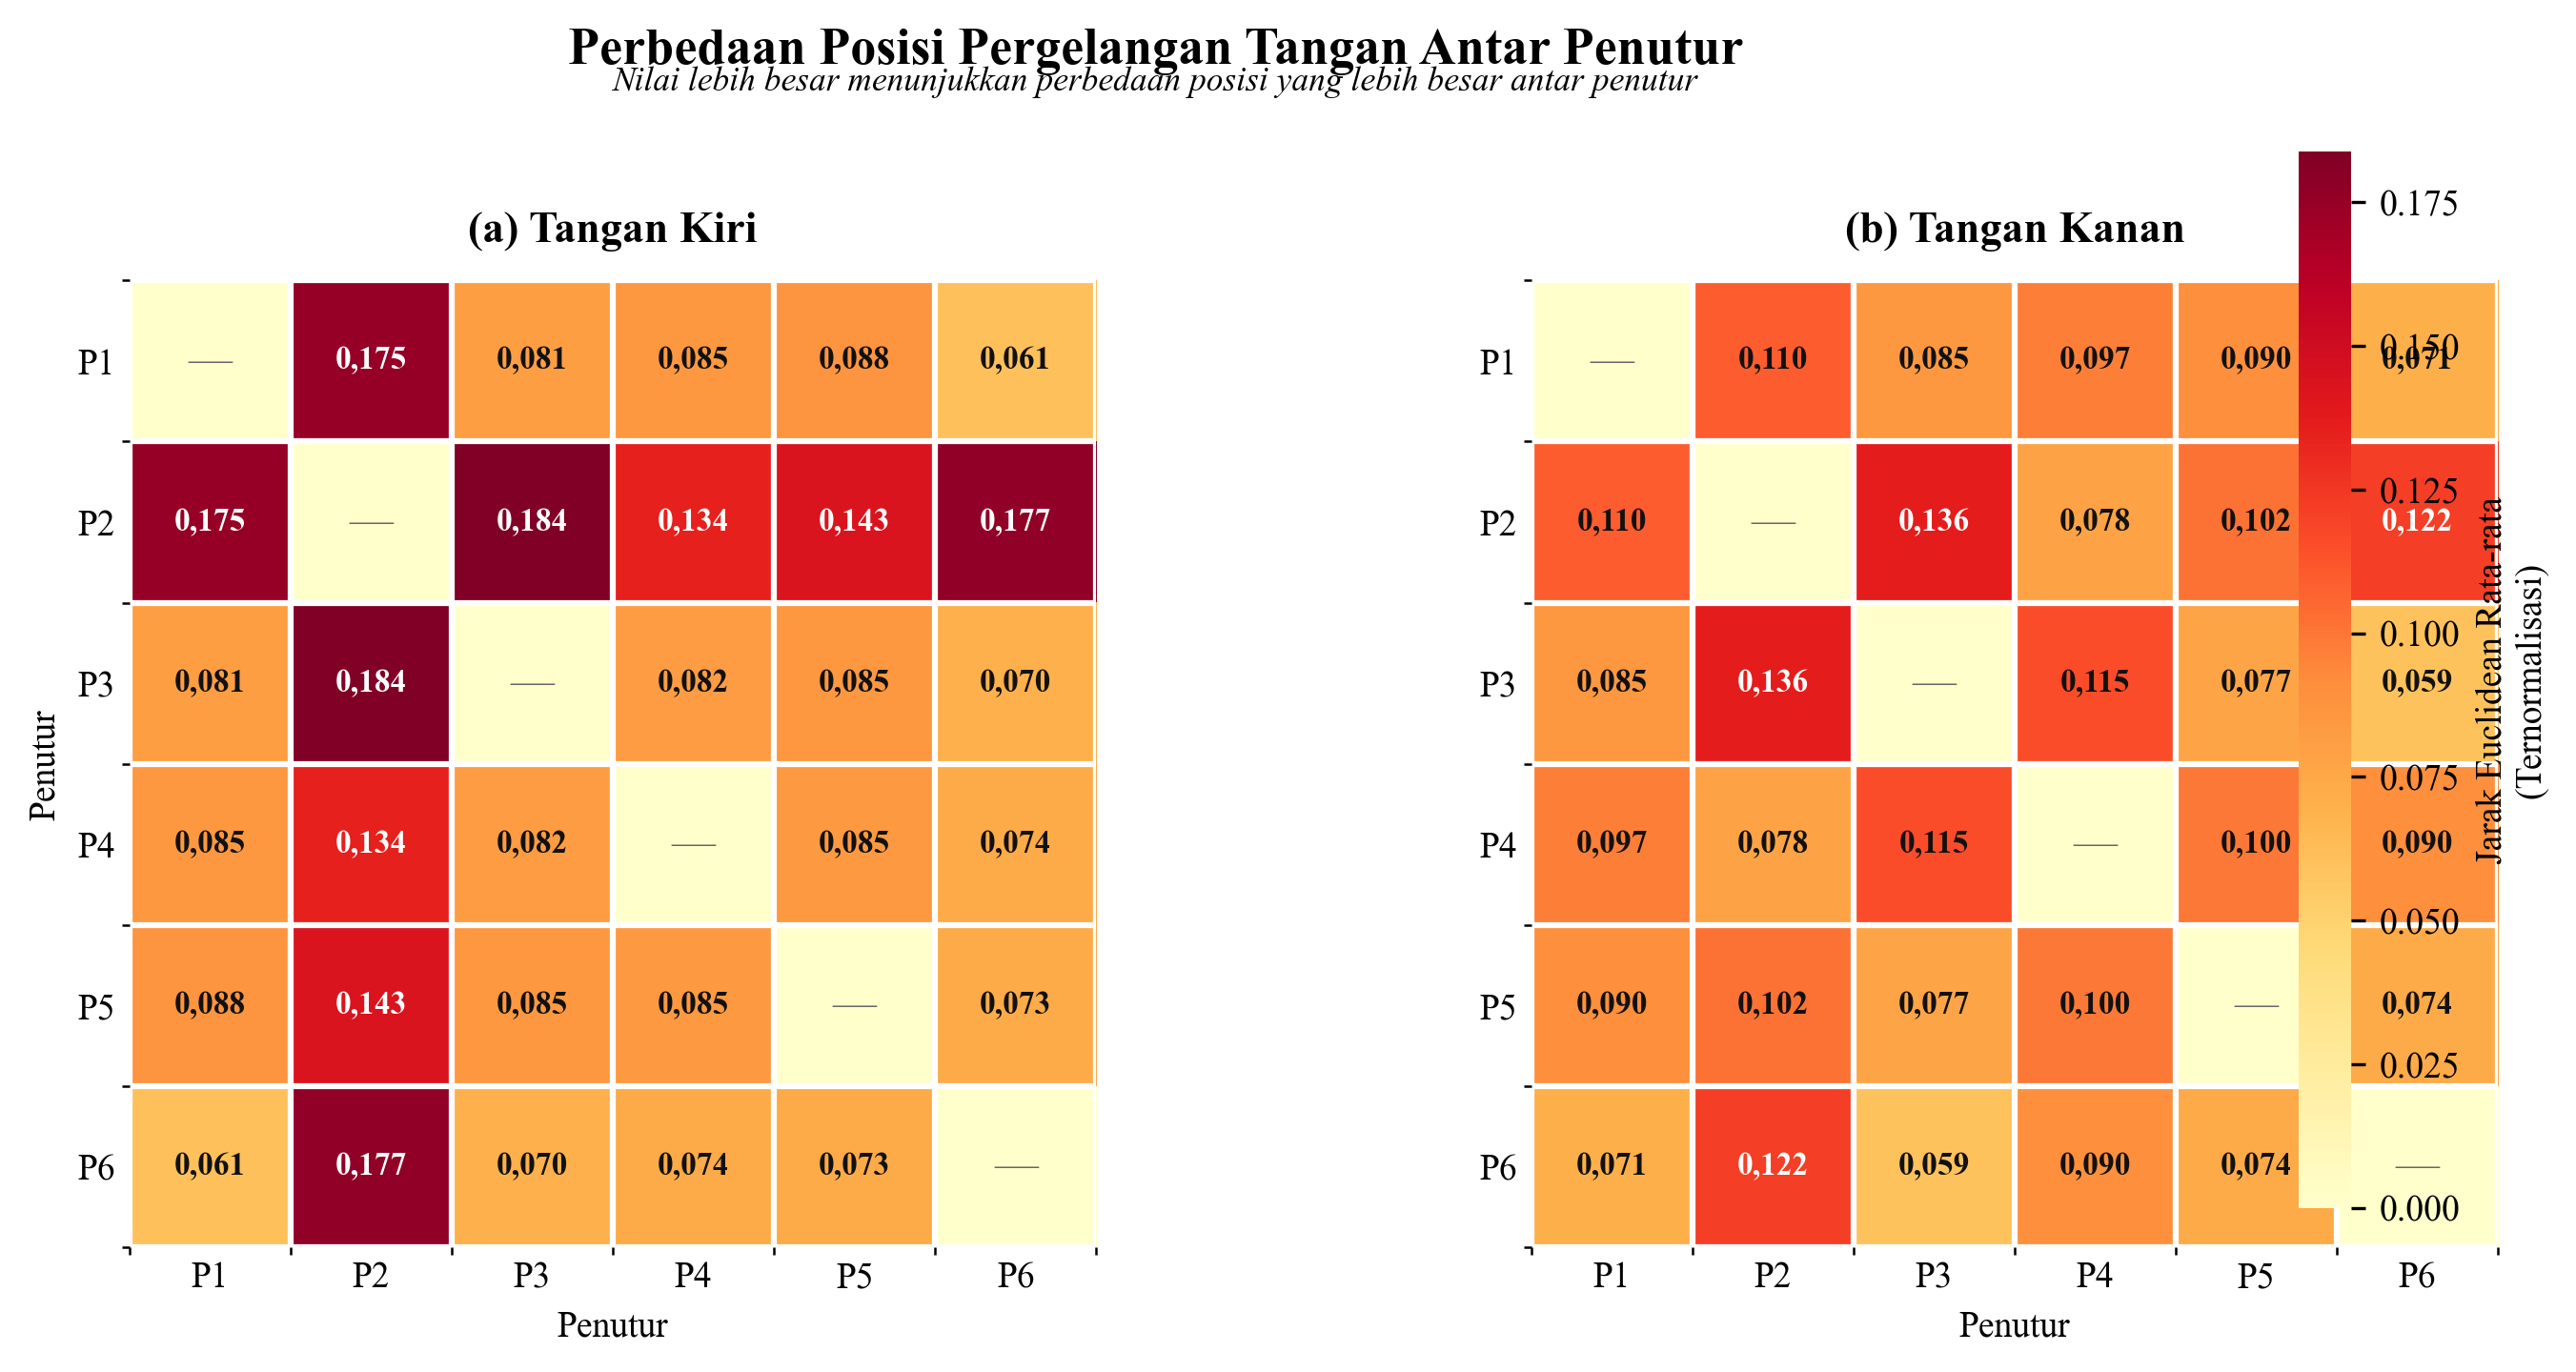

[SAVED] ../data/results\spatial_pairwise_heatmap_fullmatrix.png


In [73]:
# ── Gambar 2: Full Pairwise Distance Heatmap ────────────────────────────────

# Agregasi centroid per kalimat
df_sentence = (
    df.groupby(['sentence', 'signer'])
      .agg({
          'lh_x': 'mean',
          'lh_y': 'mean',
          'rh_x': 'mean',
          'rh_y': 'mean'
      })
      .reset_index()
)

n = len(speakers)

dist_mat_lh = np.zeros((n, n))
dist_mat_rh = np.zeros((n, n))

# ── Pairwise Available Sentences ────────────────────────────────────────────

for i, sp1 in enumerate(speakers):
    for j, sp2 in enumerate(speakers):

        if i == j:
            continue

        # Kalimat yang dimiliki kedua signer
        pair_df = df_sentence[
            df_sentence['signer'].isin([sp1, sp2])
        ]

        common_sentences = (
            pair_df.groupby('sentence')['signer']
                   .nunique()
        )

        common_sentences = common_sentences[
            common_sentences == 2
        ].index

        pair_df = pair_df[
            pair_df['sentence'].isin(common_sentences)
        ]

        if len(common_sentences) == 0:
            dist_mat_lh[i, j] = np.nan
            dist_mat_rh[i, j] = np.nan
            continue

        lh = pair_df.pivot(
            index='sentence',
            columns='signer',
            values=['lh_x', 'lh_y']
        )

        rh = pair_df.pivot(
            index='sentence',
            columns='signer',
            values=['rh_x', 'rh_y']
        )

        dist_l = np.sqrt(
            (lh['lh_x'][sp1] - lh['lh_x'][sp2])**2 +
            (lh['lh_y'][sp1] - lh['lh_y'][sp2])**2
        )

        dist_r = np.sqrt(
            (rh['rh_x'][sp1] - rh['rh_x'][sp2])**2 +
            (rh['rh_y'][sp1] - rh['rh_y'][sp2])**2
        )

        dist_mat_lh[i, j] = dist_l.mean()
        dist_mat_rh[i, j] = dist_r.mean()

# Diagonal = 0
np.fill_diagonal(dist_mat_lh, 0)
np.fill_diagonal(dist_mat_rh, 0)

vmax = max(
    np.nanmax(dist_mat_lh),
    np.nanmax(dist_mat_rh)
)

# ── Style ───────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 4.8),
    dpi=300
)

display_labels = speakers

def draw_heatmap(ax, data, title):

    im = ax.imshow(
        data,
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax,
        aspect='equal'
    )

    for i in range(n):
        for j in range(n):

            value = data[i, j]

            if i == j:

                ax.text(
                    j,
                    i,
                    '—',
                    ha='center',
                    va='center',
                    fontsize=11,
                    color='#666666'
                )

                continue

            txt_color = (
                'white'
                if value > vmax * 0.65
                else '#111111'
            )

            ax.text(
                j,
                i,
                f'{value:.3f}'.replace('.', ','),

                ha='center',
                va='center',

                fontsize=8,
                fontweight='semibold',

                color=txt_color
            )

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(display_labels)
    ax.set_yticklabels(display_labels)

    ax.set_xlabel('Penutur')
    ax.set_ylabel('Penutur')

    ax.set_title(
        title,
        fontsize=11,
        fontweight='bold',
        pad=10
    )

    ax.set_xticks(
        np.arange(-0.5, n, 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, n, 1),
        minor=True
    )

    ax.grid(
        which='minor',
        color='white',
        linewidth=1.5
    )

    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    return im

im = draw_heatmap(
    axes[0],
    dist_mat_lh,
    '(a) Tangan Kiri'
)

draw_heatmap(
    axes[1],
    dist_mat_rh,
    '(b) Tangan Kanan'
)

axes[1].set_ylabel('')

cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.02
)

cbar.set_label(
    'Jarak Euclidean Rata-rata\n(Ternormalisasi)',
    fontsize=9
)

cbar.outline.set_visible(False)

fig.suptitle(
    'Perbedaan Posisi Pergelangan Tangan Antar Penutur',
    fontsize=13,
    fontweight='bold',
    y=0.97
)

fig.text(
    0.5,
    0.925,
    'Nilai lebih besar menunjukkan perbedaan posisi yang lebih besar antar penutur',
    ha='center',
    fontsize=8.5,
    style='italic'
)

plt.tight_layout(
    rect=[0, 0, 0.96, 0.91]
)

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_pairwise_heatmap_fullmatrix.png'
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'[SAVED] {save_path}')